# Tutorial: Randomized Benchmarking with `errorgnomark`

Welcome to the `errorgnomark` tutorial! This notebook provides a step-by-step guide to using the framework's Randomized Benchmarking (RB) capabilities.

We will follow a logical progression, starting from generating a single abstract circuit and culminating in a complete, end-to-end Interleaved Randomized Benchmarking (IRB) experiment with data analysis and plotting.

### Learning Objectives:

*   **Part 1: Generate & Visualize a Logical RB Circuit:** Understand the high-level structure of an RB sequence.
*   **Part 2: Decompose to Physical Gates:** Learn how to translate abstract circuits into hardware-executable instructions.
*   **Part 3: Set Up an Interleaved RB (IRB) Experiment:** Isolate and measure the fidelity of a specific gate (e.g., `CZ`).
*   **Part 4: Analyze & Plot Existing Data:** Use the framework's tools to fit and visualize pre-acquired RB data.
*   **Part 5: Run an End-to-End Experiment:** Execute a full workflow, from circuit generation to simulation, analysis, and final plotting.

## Setup: Imports and Backend

First, we import the necessary components from the `errorgnomark` library and other tools like `numpy` and `matplotlib`.

The `try...except` block is designed to allow this notebook to run in two scenarios:
1.  When `errorgnomark` is properly installed as a package.
2.  When running directly from the source code repository (for development).

This tutorial assumes that a `dummy_backend` object, which simulates a noisy quantum device, has already been defined and is available in the environment. We will use this `dummy_backend` to run our circuits.

In [6]:
# --- Standard Library Imports ---
import numpy as np
import logging
from typing import List, Dict, Any, Union
import matplotlib.pyplot as plt

# --- Simplified Framework Imports ---
# NOTE: For this simple import to work, your project must be correctly 
# installed in your Python environment. See the instructions below.

from errorgnomark.circuits.circuit import QuantumCircuit,Gate
from errorgnomark.experiments.benchmarking.rb import StandardRBExperiment, InterleavedRBExperiment
from errorgnomark.analysis.rb import fit_rb_data,calculate_epg,analyze_epg,plot_rb_single,plot_rb_comparison

# Configure logging
logging.basicConfig(level=logging.INFO)

print("Successfully imported 'errorgnomark' modules.")

Successfully imported 'errorgnomark' modules.


## Part 1: Generate a Logical RB Circuit

Let's start by creating a `StandardRBExperiment` for two qubits. We can then ask it to generate a single logical (or abstract) RB circuit of a specific depth. This circuit consists of abstract Clifford group elements and does not yet specify the exact gate sequence.

In [28]:
# 1. Define the experiment parameters
qubits = [0, 1]
rb_exp_logical = StandardRBExperiment(qubits=qubits, seed=42)

# 2. Generate a single logical circuit with depth m=5
# --- FIX ---
# The 'decompose' argument is not part of the function's definition.
# Decomposition is controlled by whether 'native_gates' is set when creating the StandardRBExperiment object.
# Since we did not set it, the circuit will correctly remain logical (not decomposed).
logical_circuit = rb_exp_logical.generate_single_circuit(depth=2) # REMOVED: decompose=False

# 3. Print and visualize the circuit
print(logical_circuit)
print("\n--- Circuit Visualization ---")
logical_circuit.draw()

[INFO] RB Experiment configured for LOGICAL view (`native_gates=None`).


QuantumCircuit(qubits=[0, 1], num_gates=32)

--- Circuit Visualization ---
q0:     ┤  Y  ├┤  X  ├───●───┤  X  ├┤  S  ├┤  S  ├───●───┤  Y  ├┤  H  ├┤  H  ├┤  Y  ├───●───┤ SDG ├┤ SDG ├┤  X  ├───●───┤  X  ├┤  Y  ├── M ──
q1:     ┤  Y  ├┤  X  ├───⊕───┤  Y  ├┤  S  ├┤  H  ├───⊕───┤  S  ├┤ SDG ├─────────────────⊕───┤  H  ├┤ SDG ├┤  Y  ├───⊕───┤  X  ├┤  Y  ├── M ──


## Part 2: Decompose to Physical Gates

Real hardware cannot execute abstract 'Clifford' gates. They must be *decomposed* into a set of basis gates that the hardware supports, known as `native_gates`.

Let's create a new experiment, this time specifying a native gate set. When we generate a circuit now, it will be automatically decomposed.

In [33]:
# Assume 'qubits' is defined from the previous cell, e.g., qubits = [0, 1]

# 1. Define the native gate set for our hardware


# Native gates for typical CZ-based platforms (e.g., Rigetti, Google)
# SUPERCONDUCTING_CZ_NATIVE_GATES: List[str] = [
#     'cz', 'h', 's', 'sdg', 't', 'tdg', 'x', 'y', 'z', 'id',
#     'rx90', 'rxm90', 'ry90', 'rym90', 'sqrtx'
# ]

# e.g. native_gates = ['sx', 'rz', 'cz']

native_gates =[
    'cz', 'h', 's', 'sdg', 't', 'tdg', 'x', 'y', 'z', 'id',
    'rx90', 'rxm90', 'ry90', 'rym90', 'sqrtx'
]

# 2. Create an experiment instance with the native gate set
# By providing 'native_gates' here, you are instructing the experiment
# to automatically decompose all circuits it generates into this basis.
rb_exp_physical = StandardRBExperiment(qubits=qubits, native_gates=native_gates, seed=42)

# 3. Generate a circuit of depth m=2. It will be automatically decomposed.
# We use a smaller depth because decomposition results in many more gates.

# --- FIX ---
# Removed the 'decompose=True' argument. The decomposition happens automatically
# because 'native_gates' was specified when creating the 'rb_exp_physical' object.
physical_circuit = rb_exp_physical.generate_single_circuit(depth=2)

# 4. Print and visualize the decomposed circuit
print(f"Circuit contains {len(physical_circuit.gates)} native gates.")
print("\n--- Decomposed Circuit Visualization (first 20 gates) ---")
# Drawing the full circuit can be very long, so we can't show it here.
physical_circuit.draw()

[INFO] RB Experiment configured for PHYSICAL view. Decomposing to: ['cz', 'h', 's', 'sdg', 't', 'tdg', 'x', 'y', 'z', 'id', 'rx90', 'rxm90', 'ry90', 'rym90', 'sqrtx']


Circuit contains 46 native gates.

--- Decomposed Circuit Visualization (first 20 gates) ---
q0:     ┤ SDG ├┤  H  ├──────────●───┤  X  ├┤  S  ├┤  S  ├───────────────────────────────●───┤  H  ├┤ SDG ├┤  S  ├┤  H  ├─────────────────●───┤ SDG ├┤ SDG ├┤  X  ├───────────────────────────────●───┤  H  ├┤  S  ├── M ─────────
q1:     ┤  S  ├┤  H  ├┤  H  ├───●───┤  H  ├┤  H  ├┤  X  ├┤  H  ├┤  Y  ├┤  H  ├┤  H  ├───●───┤  H  ├┤  S  ├┤  H  ├┤  H  ├┤ SDG ├┤  H  ├───●───┤  H  ├┤  H  ├┤  Y  ├┤  H  ├┤  X  ├┤  H  ├┤  H  ├───●───┤  H  ├┤  H  ├┤ SDG ├── M ──


## Part 3: Set Up an Interleaved RB (IRB) Experiment

Interleaved Randomized Benchmarking (IRB) is used to measure the fidelity of a specific gate. It works by sandwiching (interleaving) the target gate between each random Clifford in the sequence.

Here, we'll set up an IRB experiment to characterize the `CZ` gate.

In [26]:
# ==============================================================================
#  Tutorial Example: Generating a Physical Interleaved RB Circuit with errorgnomark
# ==============================================================================
#
# Objective: This example demonstrates how to configure an Interleaved RB
#            experiment to automatically generate circuits that are decomposed
#            to the "physical level".
#
# ==============================================================================

# --- Step 0: Import necessary components ---
# Assuming these modules are available in your environment.
from errorgnomark.experiments.benchmarking.rb import InterleavedRBExperiment
from errorgnomark.circuits.circuit import Gate
from IPython.display import display

# Assume 'qubits' is defined from a previous cell, e.g.:
qubits = [0, 1]

# --- Step 1: Define the "native gate" set supported by our hardware ---
# This is the instruction set we want the final circuit to be expressed in.
native_gates = ['sx', 'rz', 'cz']

# --- Step 2: Define the "interleaved gate" we want to benchmark ---
# According to the errorgnomark API, this needs to be a Gate object.
# Note: The logic and purpose of the IRB experiment still hold true even if
# the interleaved gate itself (like 'cz' here) is already one of the native gates.
interleaved_gate = Gate(name="cz", qubits=qubits)

# --- Step 3: Create an InterleavedRBExperiment instance with the native gate configuration ---
#
# By providing the 'native_gates' argument here, you are instructing the experiment:
# "All circuits you generate must be automatically decomposed into this gate set."
irb_exp_physical = InterleavedRBExperiment(
    qubits=qubits,
    interleaved_gate=interleaved_gate,
    native_gates=native_gates,
    seed=42  # Using a fixed seed to ensure reproducible results
)

# --- Step 4: Generate a circuit with depth m=2 ---
#
# We choose a small depth because the decomposed circuit will contain
# a very large number of gates.
#
# --- Key Point ---
# The decomposition process happens automatically. Because we specified 'native_gates'
# when creating the 'irb_exp_physical' object, the 'generate_single_circuit'
# method handles the decomposition logic internally. We do not need to pass
# any extra arguments.
physical_irb_circuit = irb_exp_physical.generate_single_circuit(depth=2)

# --- Step 5: Print information and visualize the decomposed circuit ---
physical_irb_circuit.draw()


[INFO] RB Experiment configured for PHYSICAL view. Decomposing to: ['sx', 'rz', 'cz']


q0:     ┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(1…├┤ SX  ├───●───┤ SX  ├┤RZ(1…├┤ SX  ├┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(3…├┤ SX  ├┤RZ(1…├┤ SX  ├┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(3…├┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(3…├┤ SX  ├┤RZ(1…├┤ SX  ├───●───┤RZ(3…├┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(3…├┤ SX  ├┤RZ(1…├┤ SX  ├┤ SX  ├┤RZ(1…├┤ SX  ├────────────────────────●───┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(3…├┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(1…├────────────────────────●───┤RZ(-…├┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(3…├┤ SX  ├┤RZ(1…├┤ SX  ├────────────────────────●───┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(3…├┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(3…├┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(3…├┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(3…├┤ SX  ├┤RZ(1…├┤ SX  ├┤ SX  ├┤RZ(1…├┤ SX  ├┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(3…├┤ SX  ├┤RZ(1…├┤ SX  ├┤ SX  ├┤RZ(1…├┤ SX  ├───●───┤ SX  ├┤RZ(1…├┤ SX  ├┤RZ(-…├┤ SX  ├┤RZ(1…├┤ SX  ├── M ──
q1:     ┤ SX  ├┤RZ(1…├┤ SX  ├───────────────────────────────●───┤ SX  ├┤RZ(1…├┤ SX  ├┤ SX  ├┤RZ(1…├┤ SX  ├────────────────────────────────────────────────────────────────────────────────────────────────────────────●───┤RZ

## Part 4: Analyze & Plot Existing Data

The `errorgnomark` library includes powerful tools for analyzing and plotting RB data. Let's imagine we have already run an experiment and collected the following survival probabilities.

We can use `fit_rb_data` to fit the exponential decay curve and `plot_rb_single` to visualize the result.

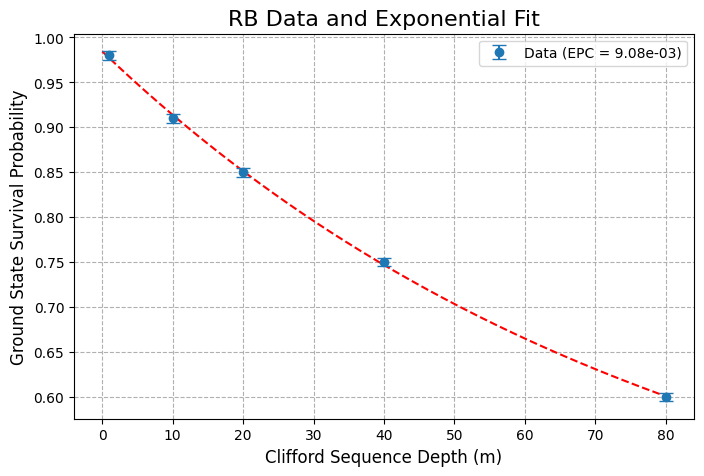

In [16]:
import matplotlib.pyplot as plt

# Assume 'qubits', 'fit_rb_data', and 'plot_rb_single' 
# are already defined in your environment.
# For example:
qubits = [0, 1] 
# from errorgnomark.analysis.rb import fit_rb_data, plot_rb_single

# 1. Some pre-collected dummy data
# This dictionary maps sequence depth (m) to a list of survival probabilities from different random circuits.
dummy_data = {
    1: [0.98, 0.99, 0.97], 
    10: [0.91, 0.92, 0.90], 
    20: [0.85, 0.86, 0.84],
    40: [0.74, 0.75, 0.76],
    80: [0.60, 0.61, 0.59]
}

# 2. Use the analysis function to fit the data
analysis_results = fit_rb_data(dummy_data, num_qubits=len(qubits))

# --- Correction 1: How to access the dictionary ---
# 'p' and 'epc' are at the top level of analysis_results, not inside 'fit_params'.
# Additionally, the provided fit_rb_data function does not calculate parameter errors (p_err, epc_err),
# so we have removed them from the print statement.

# 3. Use the plotting function to visualize the data and the fit
fig, ax = plt.subplots(figsize=(8, 5))

# --- Correction 2: How to call the plotting function ---
# The parameters for the plot_rb_single function should be `results`, `num_qubits`, and `title`.
# We pass `analysis_results` as the `results` argument.
plot_rb_single(
    ax=ax,
    results=analysis_results, 
    num_qubits=len(qubits),
    title="RB Data and Exponential Fit"
)
# The ax.set_title() line can be omitted, as the title is already passed to the plotting function.
plt.show()

## Part 5: Run an End-to-End Experiment

Now, let's tie everything together. We will perform a complete RB and IRB experiment workflow:

1.  **Define Experiments**: Set up both `StandardRBExperiment` and `InterleavedRBExperiment`.
2.  **Generate & Run Circuits**: Create a full set of circuits for various depths and run them on the backend.
3.  **Process and Analyze Data**: Fit the results for both experiments.
4.  **Calculate Gate Error**: Use the EPC from both fits to find the error of the interleaved gate (`CZ`).
5.  **Plot Comparison**: Visualize both decay curves on the same plot.

[INFO] QuantumEngine initialized with backend 'DummyBackend' and is ready.
[INFO] RB Experiment configured for PHYSICAL view. Decomposing to: ['cz', 'sx', 'rz']
[INFO] 
--- Running Full Interleaved 2-Qubit RB for gate 'CZ' ---
[INFO] [Step 1/3] Running Standard RB reference experiment...
[INFO] RB Experiment configured for PHYSICAL view. Decomposing to: ['cz', 'sx', 'rz']
[INFO] --- Running Standard 2-Qubit RB ---


Initializing Backend and Engine...
DummyBackend initialized with a phenomenological model: 
  Clifford Fidelity p_C = 0.98
  Gate Fidelities p_G = {'cz': 0.99}
  SPAM Parameters: A=0.995, B=0.005

Defining the Interleaved RB Experiment...
--- Running the full experiment workflow ---


[INFO] Generated 175 circuits. Executing on backend...
[INFO] Executing 175 circuits with 1024 shots each on backend 'DummyBackend'...
[INFO]   ... processing circuit 10/175
[INFO]   ... processing circuit 20/175
[INFO]   ... processing circuit 30/175
[INFO]   ... processing circuit 40/175
[INFO]   ... processing circuit 50/175
[INFO]   ... processing circuit 60/175
[INFO]   ... processing circuit 70/175
[INFO]   ... processing circuit 80/175
[INFO]   ... processing circuit 90/175
[INFO]   ... processing circuit 100/175
[INFO]   ... processing circuit 110/175
[INFO]   ... processing circuit 120/175
[INFO]   ... processing circuit 130/175
[INFO]   ... processing circuit 140/175
[INFO]   ... processing circuit 150/175
[INFO]   ... processing circuit 160/175
[INFO]   ... processing circuit 170/175
[INFO]   ... processing circuit 175/175
[INFO] Execution complete.
[INFO] Fitting RB data...
[INFO] Fit successful. EPC = 1.480e-02
[INFO] Standard RB Reference Fit successful. EPC = 1.480e-02
[

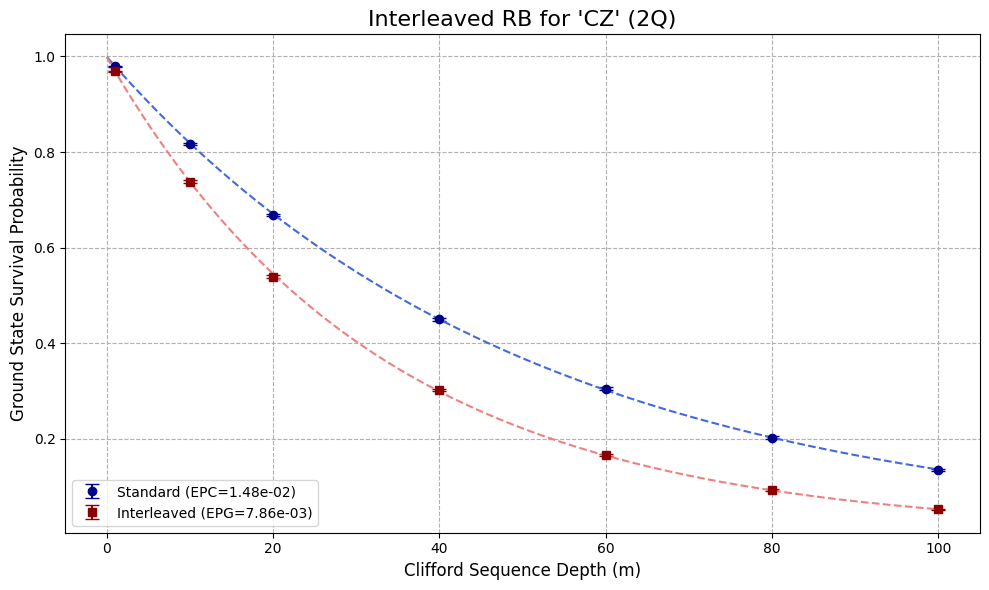

In [22]:
# =========================================================================
# Final User Script: Directly Invokes Your Interleaved RB Experiment Framework
#
# This script assumes the 'errorgnomark' library and the 'rb.py' file
# are correctly installed and accessible in the Python environment.
# =========================================================================

# Step 1: Import all necessary components from your library
# -------------------------------------------------------------------------
# Import the experiment class from your local experiment module
from errorgnomark.experiments.benchmarking.rb import InterleavedRBExperiment

# Import core components from the 'errorgnomark' library
from errorgnomark.engine import QuantumEngine
from errorgnomark.circuits import Gate
from errorgnomark.backends import DummyBackend


# Step 2: Prepare the Backend and Engine
# -------------------------------------------------------------------------
# Instantiate a backend to simulate a device with specific noise characteristics
print("Initializing Backend and Engine...")
my_backend = DummyBackend(
    clifford_fidelity=0.98,
    gate_fidelities={'cz': 0.99},
    spam_error_rate=0.005
)

# Initialize the Quantum Engine with the configured backend
my_engine = QuantumEngine(backend=my_backend)


# Step 3: Define and Configure the Interleaved RB Experiment
# -------------------------------------------------------------------------
# Directly instantiate the experiment class
print("\nDefining the Interleaved RB Experiment...")
irb_experiment = InterleavedRBExperiment(
    qubits=[0, 1],
    interleaved_gate=Gate('cz', qubits=[0, 1]),
    depths=[1, 10, 20, 40, 60, 80, 100],
    circuits_per_depth=25,
    native_gates=['cz', 'sx', 'rz'],
    seed=42
)


# Step 4: Execute the Experiment
# -------------------------------------------------------------------------
# This single .run() call handles all internal logic: circuit generation,
# execution, analysis, and plotting.
print("--- Running the full experiment workflow ---")
results = irb_experiment.run(
    engine=my_engine,
    shots=1024,
    plot=True  # Automatically display the results plot
)